Eleanor Stoever

AM 170B

Implementing mHAVOK on the Lorenz system

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.integrate import solve_ivp # for SVD
from sklearn.linear_model import LinearRegression # for computing bst fit linear system

# we are implementing mHAVOK manually now, so no need for pydmd's HAVOK

In [2]:
from scipy.integrate import solve_ivp
import numpy as np

# Define Lorenz Function

def generate_lorenz_data(t_eval):

    def lorenz_system(t, state):
        sigma, rho, beta = 10, 28, 8/3

        x, y, z = state

        dxdt = sigma * (y - x)
        dydt = x * (rho - z) - y
        dzdt = x * y - beta * z

        return [dxdt, dydt, dzdt]

    sol = solve_ivp(
        lorenz_system,
        [t_eval[0], t_eval[-1]],
        [-8, 8, 27],
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-12,
        atol=1e-12,
    )

    return sol.y

In [3]:
dt = 0.001
m = 50000

t = np.arange(m) * dt

X = generate_lorenz_data(t)

In [4]:
# Generate Lorenz data
dt = 0.001
m = 50000
t = np.arange(m) * dt
X = generate_lorenz_data(t)

# mHAVOK input channels
# use multiple observables:
Y = X[[0, 2], :]   # channels: x and z
# Y shape = number_of_channels * time

In [5]:
# Build multichannel Hankel matrix
delays = 100

def build_hankel(signal, delays):
    """
    signal is 1D: length m
    returns Hankel delay matrix
    """
    return np.array([
        signal[i : i + len(signal) - delays + 1]
        for i in range(delays)
    ])

H_list = []

for channel in Y:
    H_channel = build_hankel(channel, delays)
    H_list.append(H_channel)

# stack each channel's hankel matrix vertically
H = np.vstack(H_list)

In [9]:
# SVD
U, S, Vh = np.linalg.svd(H, full_matrices=False)

# chose rank (for now, work on better ranking system later)
r = 9

V = Vh[:r, :].T
# Each Hankel column ends at sample index delays - 1 + j.
time_havok = t[delays - 1 : delays - 1 + V.shape[0]]

In [7]:
# Regression
# Use first r-1 modes as linear state
# Use last mode as forcing
V_linear = V[:, :r-1]
forcing = V[:, r-1]

# Approximate time derivative
dVdt = np.gradient(V_linear, dt, axis=0)

# Regression input = [linear states, forcing]
Theta = np.column_stack([V_linear, forcing])

model = LinearRegression(fit_intercept=False)
model.fit(Theta, dVdt)

Xi = model.coef_.T

A = Xi[:r-1, :]
B = Xi[r-1:, :]

print("A shape:", A.shape)
print("B shape:", B.shape)

A shape: (8, 8)
B shape: (1, 8)


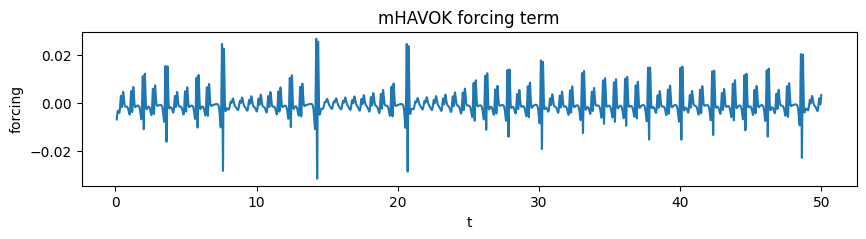

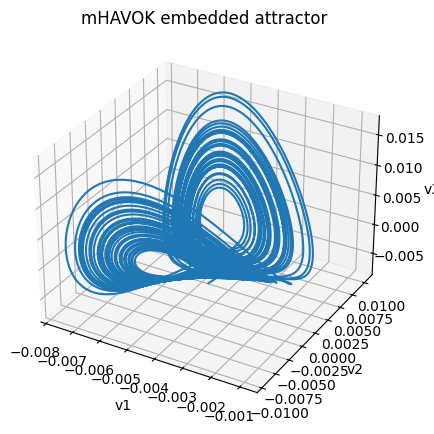

In [10]:
# Plot forcing term
plt.figure(figsize=(10, 2))
plt.plot(time_havok, forcing)
plt.title("mHAVOK forcing term")
plt.xlabel("t")
plt.ylabel("forcing")
plt.show()

# Plot embedded attractor
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(V_linear[:, 0], V_linear[:, 1], V_linear[:, 2])
ax.set_title("mHAVOK embedded attractor")
ax.set_xlabel("v1")
ax.set_ylabel("v2")
ax.set_zlabel("v3")
plt.show()

In [11]:
# Lorenz lobe-switch analysis

def get_ind_switch_lorenz(x):
    ind_switch = np.sign(x[:-1]) - np.sign(x[1:]) != 0
    ind_switch = np.append(ind_switch, False)
    return np.where(ind_switch)[0]

forcing_threshold = np.quantile(np.abs(forcing), 0.95)
active_forcing = np.abs(forcing) >= forcing_threshold
active_times = time_havok[active_forcing]
switch_indices = get_ind_switch_lorenz(X[0])
switch_times = t[switch_indices]

nearest_signed_gaps = []
for switch_time in switch_times:
    time_diffs = active_times - switch_time
    nearest_signed_gaps.append(time_diffs[np.argmin(np.abs(time_diffs))])

nearest_signed_gaps = np.array(nearest_signed_gaps)

print(f"Number of Lorenz lobe switches: {len(switch_times)}")
print(f"95th percentile forcing threshold: {forcing_threshold:.4f}")
print(f"Median absolute gap to nearest active forcing event: {np.median(np.abs(nearest_signed_gaps)):.4f} s")
print(f"Median signed gap: {np.median(nearest_signed_gaps):.4f} s")
print(f"Fraction of switches preceded by nearest active forcing event: {np.mean(nearest_signed_gaps <= 0):.3f}")
print(f"Fraction within 0.10 s: {np.mean(np.abs(nearest_signed_gaps) <= 0.10):.3f}")
print(f"Fraction within 0.25 s: {np.mean(np.abs(nearest_signed_gaps) <= 0.25):.3f}")
print(f"Fraction within 0.50 s: {np.mean(np.abs(nearest_signed_gaps) <= 0.50):.3f}")

Number of Lorenz lobe switches: 28
95th percentile forcing threshold: 0.0093
Median absolute gap to nearest active forcing event: 0.0885 s
Median signed gap: -0.0620 s
Fraction of switches preceded by nearest active forcing event: 0.786
Fraction within 0.10 s: 0.607
Fraction within 0.25 s: 0.786
Fraction within 0.50 s: 0.821


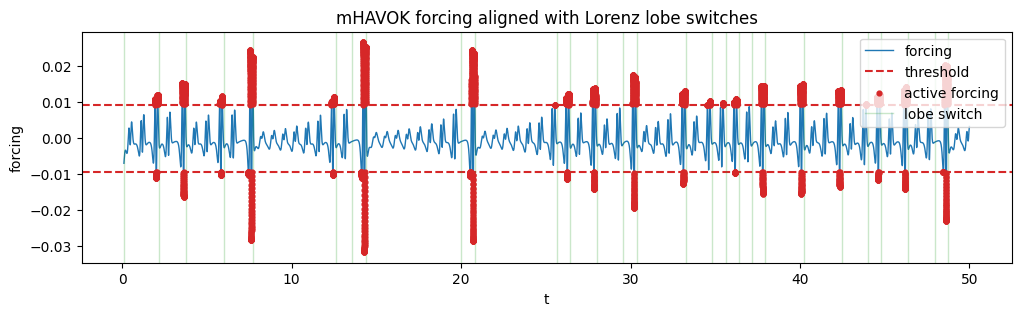

In [12]:
# Plot forcing activity against true lobe switches
plt.figure(figsize=(12, 3))
plt.plot(time_havok, forcing, label="forcing", lw=1.0)
plt.axhline(forcing_threshold, color="tab:red", linestyle="--", label="threshold")
plt.axhline(-forcing_threshold, color="tab:red", linestyle="--")
plt.scatter(
    time_havok[active_forcing],
    forcing[active_forcing],
    color="tab:red",
    s=12,
    label="active forcing",
    zorder=3,
)
for idx, switch_time in enumerate(switch_times):
    label = "lobe switch" if idx == 0 else None
    plt.axvline(switch_time, color="tab:green", alpha=0.25, linewidth=1.0, label=label)
plt.title("mHAVOK forcing aligned with Lorenz lobe switches")
plt.xlabel("t")
plt.ylabel("forcing")
plt.legend(loc="upper right")
plt.show()

Top mHAVOK settings by switch alignment:
delays=150, rank=13, median |gap|=0.0275 s, median signed gap=0.0000 s, fraction within 0.10 s=0.607
delays=150, rank=11, median |gap|=0.0480 s, median signed gap=0.0000 s, fraction within 0.10 s=0.643
delays=150, rank=9, median |gap|=0.0585 s, median signed gap=-0.0250 s, fraction within 0.10 s=0.679
delays=100, rank=13, median |gap|=0.0585 s, median signed gap=-0.0050 s, fraction within 0.10 s=0.643
delays=100, rank=11, median |gap|=0.0775 s, median signed gap=-0.0230 s, fraction within 0.10 s=0.607

Top mHAVOK settings by event metrics (tolerance=0.10 s):
delays=150, rank=11, recall=0.643, precision=0.254, accuracy=0.880, F1=0.364, mean linear R²=0.938, chamfer=0.2352 s
delays=100, rank=13, recall=0.643, precision=0.225, accuracy=0.877, F1=0.333, mean linear R²=0.950, chamfer=0.2441 s
delays=150, rank=13, recall=0.607, precision=0.221, accuracy=0.887, F1=0.324, mean linear R²=0.949, chamfer=0.2740 s
delays=150, rank=9, recall=0.500, precision

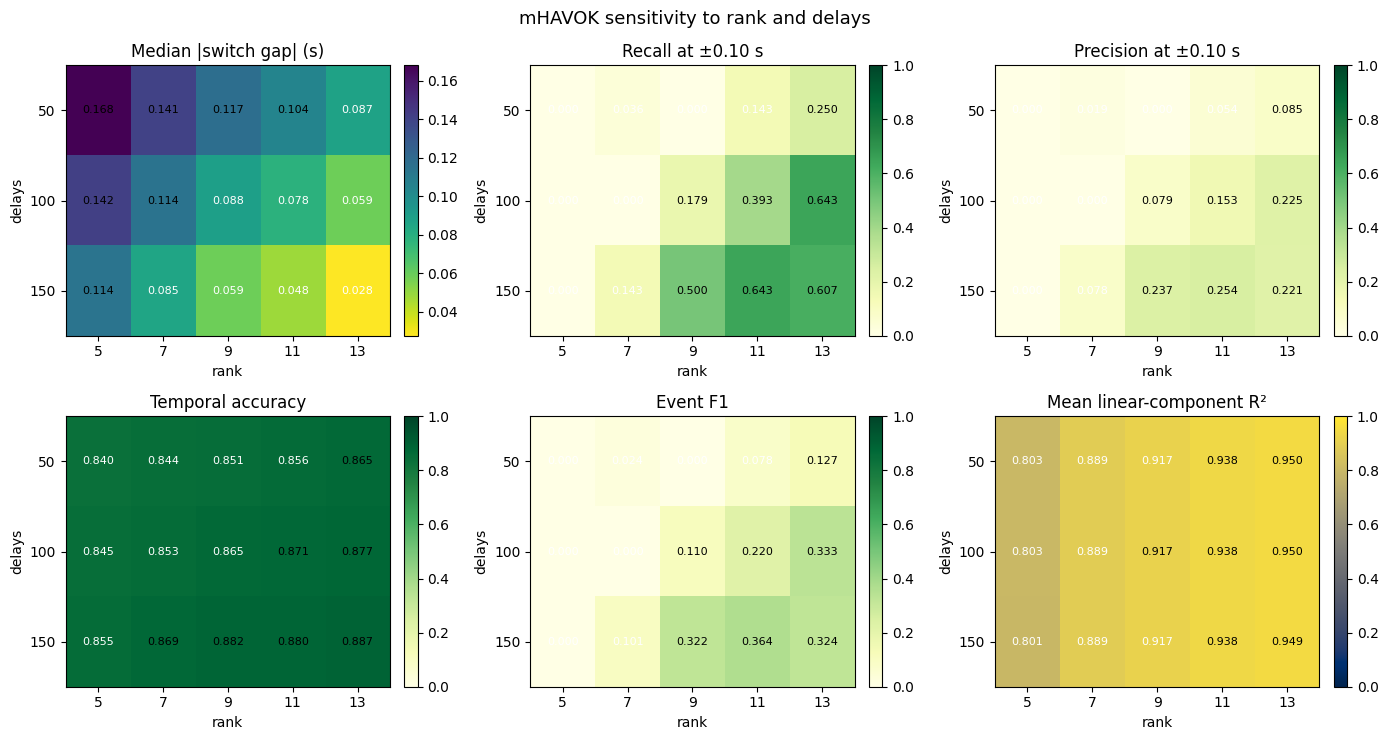

In [22]:
# Small rank/delay sweep for switch alignment and event-detection metrics
import pandas as pd


def get_event_onset_indices(active_mask):
    transitions = np.diff(active_mask.astype(int))
    onset_indices = np.where(transitions == 1)[0] + 1
    if active_mask[0]:
        onset_indices = np.insert(onset_indices, 0, 0)
    return onset_indices


def match_event_times(reference_times, candidate_times, tolerance):
    reference_times = np.asarray(reference_times)
    candidate_times = np.asarray(candidate_times)
    matched_reference = np.zeros(len(reference_times), dtype=bool)
    matched_candidate = np.zeros(len(candidate_times), dtype=bool)

    reference_index = 0
    candidate_index = 0
    while reference_index < len(reference_times) and candidate_index < len(candidate_times):
        time_gap = candidate_times[candidate_index] - reference_times[reference_index]
        if abs(time_gap) <= tolerance:
            matched_reference[reference_index] = True
            matched_candidate[candidate_index] = True
            reference_index += 1
            candidate_index += 1
        elif time_gap < -tolerance:
            candidate_index += 1
        else:
            reference_index += 1

    return matched_reference, matched_candidate


def compute_temporal_labels(time_vector, event_times, tolerance):
    labels = np.zeros_like(time_vector, dtype=bool)
    for event_time in event_times:
        labels |= np.abs(time_vector - event_time) <= tolerance
    return labels


def compute_component_r2_scores(target_matrix, prediction_matrix):
    component_scores = []
    for component_index in range(target_matrix.shape[1]):
        target = target_matrix[:, component_index]
        prediction = prediction_matrix[:, component_index]
        ss_res = np.sum((target - prediction) ** 2)
        ss_tot = np.sum((target - target.mean()) ** 2)
        component_scores.append(1 - ss_res / ss_tot if ss_tot > 0 else 0.0)
    return np.array(component_scores)


def chamfer_distance_1d(reference_times, candidate_times):
    if len(reference_times) == 0 or len(candidate_times) == 0:
        return np.inf
    pairwise_distances = np.abs(
        np.asarray(reference_times)[:, None] - np.asarray(candidate_times)[None, :]
    )
    return 0.5 * (
        np.mean(np.min(pairwise_distances, axis=1))
        + np.mean(np.min(pairwise_distances, axis=0))
    )


def build_metric_grid(records, row_values, col_values, metric_key):
    grid = np.full((len(row_values), len(col_values)), np.nan)
    for row_index, trial_delays in enumerate(row_values):
        for col_index, trial_rank in enumerate(col_values):
            for record in records:
                if record["delays"] == trial_delays and record["rank"] == trial_rank:
                    grid[row_index, col_index] = record[metric_key]
                    break
    return grid


def evaluate_mhavok_configuration(
    Y,
    t,
    dt,
    switch_times,
    delays,
    rank,
    forcing_quantile=0.95,
    event_tolerance=0.10,
    return_series=False,
):
    H = np.vstack([build_hankel(channel, delays) for channel in Y])
    U, S, Vh = np.linalg.svd(H, full_matrices=False)
    V = Vh[:rank, :].T
    time_havok = t[delays - 1 : delays - 1 + V.shape[0]]
    forcing = V[:, rank - 1]
    V_linear = V[:, : rank - 1]

    dVdt = np.gradient(V_linear, dt, axis=0)
    Theta = np.column_stack([V_linear, forcing])
    model = LinearRegression(fit_intercept=False)
    model.fit(Theta, dVdt)

    Xi = model.coef_.T
    A = Xi[: rank - 1, :]
    B = Xi[rank - 1 :, :]
    dVdt_pred = Theta @ Xi
    component_r2 = compute_component_r2_scores(dVdt, dVdt_pred)

    forcing_threshold = np.quantile(np.abs(forcing), forcing_quantile)
    active_forcing = np.abs(forcing) >= forcing_threshold
    active_times = time_havok[active_forcing]
    event_onset_indices = get_event_onset_indices(active_forcing)
    event_times = time_havok[event_onset_indices]

    nearest_signed_gaps = []
    for switch_time in switch_times:
        time_diffs = active_times - switch_time
        nearest_signed_gaps.append(time_diffs[np.argmin(np.abs(time_diffs))])
    nearest_signed_gaps = np.array(nearest_signed_gaps)

    matched_switches, matched_events = match_event_times(
        switch_times,
        event_times,
        event_tolerance,
    )
    true_positive = int(matched_switches.sum())
    false_negative = int(len(switch_times) - true_positive)
    false_positive = int(len(event_times) - true_positive)

    event_recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0
    event_precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
    event_f1 = 0.0
    if event_precision + event_recall > 0:
        event_f1 = 2 * event_precision * event_recall / (event_precision + event_recall)

    true_labels = compute_temporal_labels(time_havok, switch_times, event_tolerance)
    pred_labels = active_forcing
    event_accuracy = float(np.mean(true_labels == pred_labels))
    chamfer_distance = float(chamfer_distance_1d(switch_times, event_times))

    result = {
        "delays": delays,
        "rank": rank,
        "median_abs_gap": float(np.median(np.abs(nearest_signed_gaps))),
        "median_signed_gap": float(np.median(nearest_signed_gaps)),
        "fraction_preceding": float(np.mean(nearest_signed_gaps <= 0)),
        "fraction_within_0p10": float(np.mean(np.abs(nearest_signed_gaps) <= 0.10)),
        "fraction_within_0p25": float(np.mean(np.abs(nearest_signed_gaps) <= 0.25)),
        "event_recall": float(event_recall),
        "event_precision": float(event_precision),
        "event_accuracy": event_accuracy,
        "event_f1": float(event_f1),
        "chamfer_distance": chamfer_distance,
        "mean_linear_r2": float(np.mean(component_r2)),
        "min_linear_r2": float(np.min(component_r2)),
        "max_linear_r2": float(np.max(component_r2)),
    }

    if return_series:
        result.update(
            {
                "forcing": forcing,
                "time_havok": time_havok,
                "active_forcing": active_forcing,
                "forcing_threshold": forcing_threshold,
                "nearest_signed_gaps": nearest_signed_gaps,
                "singular_values": S,
                "augmented_operator": Xi.T,
                "A": A,
                "B": B,
                "component_r2": component_r2,
                "event_times": event_times,
                "true_labels": true_labels,
                "pred_labels": pred_labels,
            }
        )

    return result


delay_grid = [50, 100, 150]
rank_grid = [5, 7, 9, 11, 13]
event_tolerance = 0.10
sweep_results = []
for trial_delays in delay_grid:
    for trial_rank in rank_grid:
        sweep_results.append(
            evaluate_mhavok_configuration(
                Y,
                t,
                dt,
                switch_times,
                trial_delays,
                trial_rank,
                event_tolerance=event_tolerance,
            )
        )

sorted_results = sorted(
    sweep_results,
    key=lambda row: (row["median_abs_gap"], -row["fraction_within_0p10"]),
)
metric_sorted_results = sorted(
    sweep_results,
    key=lambda row: (-row["event_f1"], -row["event_recall"], -row["event_precision"], row["chamfer_distance"]),
)
sweep_metrics_df = pd.DataFrame(sweep_results).sort_values(
    ["event_f1", "event_recall", "event_precision", "mean_linear_r2"],
    ascending=[False, False, False, False],
)

print("Top mHAVOK settings by switch alignment:")
for row in sorted_results[:5]:
    print(
        f"delays={row['delays']}, rank={row['rank']}, "
        f"median |gap|={row['median_abs_gap']:.4f} s, "
        f"median signed gap={row['median_signed_gap']:.4f} s, "
        f"fraction within 0.10 s={row['fraction_within_0p10']:.3f}"
    )

print()
print(f"Top mHAVOK settings by event metrics (tolerance={event_tolerance:.2f} s):")
for row in metric_sorted_results[:5]:
    print(
        f"delays={row['delays']}, rank={row['rank']}, "
        f"recall={row['event_recall']:.3f}, precision={row['event_precision']:.3f}, "
        f"accuracy={row['event_accuracy']:.3f}, F1={row['event_f1']:.3f}, "
        f"mean linear R²={row['mean_linear_r2']:.3f}, chamfer={row['chamfer_distance']:.4f} s"
    )

median_abs_gap_grid = build_metric_grid(sweep_results, delay_grid, rank_grid, "median_abs_gap")
recall_grid = build_metric_grid(sweep_results, delay_grid, rank_grid, "event_recall")
precision_grid = build_metric_grid(sweep_results, delay_grid, rank_grid, "event_precision")
accuracy_grid = build_metric_grid(sweep_results, delay_grid, rank_grid, "event_accuracy")
f1_grid = build_metric_grid(sweep_results, delay_grid, rank_grid, "event_f1")
linear_r2_grid = build_metric_grid(sweep_results, delay_grid, rank_grid, "mean_linear_r2")

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
heatmap_specs = [
    (median_abs_gap_grid, "viridis_r", "Median |switch gap| (s)", None, None),
    (recall_grid, "YlGn", f"Recall at ±{event_tolerance:.2f} s", 0, 1),
    (precision_grid, "YlGn", f"Precision at ±{event_tolerance:.2f} s", 0, 1),
    (accuracy_grid, "YlGn", "Temporal accuracy", 0, 1),
    (f1_grid, "YlGn", "Event F1", 0, 1),
    (linear_r2_grid, "cividis", "Mean linear-component R²", 0, 1),
]

for ax, (grid, cmap, title, vmin, vmax) in zip(axes.flat, heatmap_specs):
    image = ax.imshow(grid, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(rank_grid)))
    ax.set_xticklabels(rank_grid)
    ax.set_yticks(range(len(delay_grid)))
    ax.set_yticklabels(delay_grid)
    ax.set_xlabel("rank")
    ax.set_ylabel("delays")
    ax.set_title(title)
    finite_values = grid[np.isfinite(grid)]
    annotation_threshold = np.nanmedian(finite_values) if finite_values.size > 0 else 0.0
    for row_index, trial_delays in enumerate(delay_grid):
        for col_index, trial_rank in enumerate(rank_grid):
            value = grid[row_index, col_index]
            label = "nan" if np.isnan(value) else f"{value:.3f}"
            text_color = "white" if np.isfinite(value) and value <= annotation_threshold else "black"
            ax.text(
                col_index,
                row_index,
                label,
                ha="center",
                va="center",
                color=text_color,
                fontsize=8,
            )
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("mHAVOK sensitivity to rank and delays", fontsize=13)
plt.tight_layout()
plt.show()

Baseline configuration:
delays=100, rank=9, median |gap|=0.0885 s, median signed gap=-0.0620 s, fraction within 0.10 s=0.607

Best configuration from sweep:
delays=150, rank=13, median |gap|=0.0275 s, median signed gap=0.0000 s, fraction within 0.10 s=0.607

Improvement in median absolute switch gap: 0.0610 s


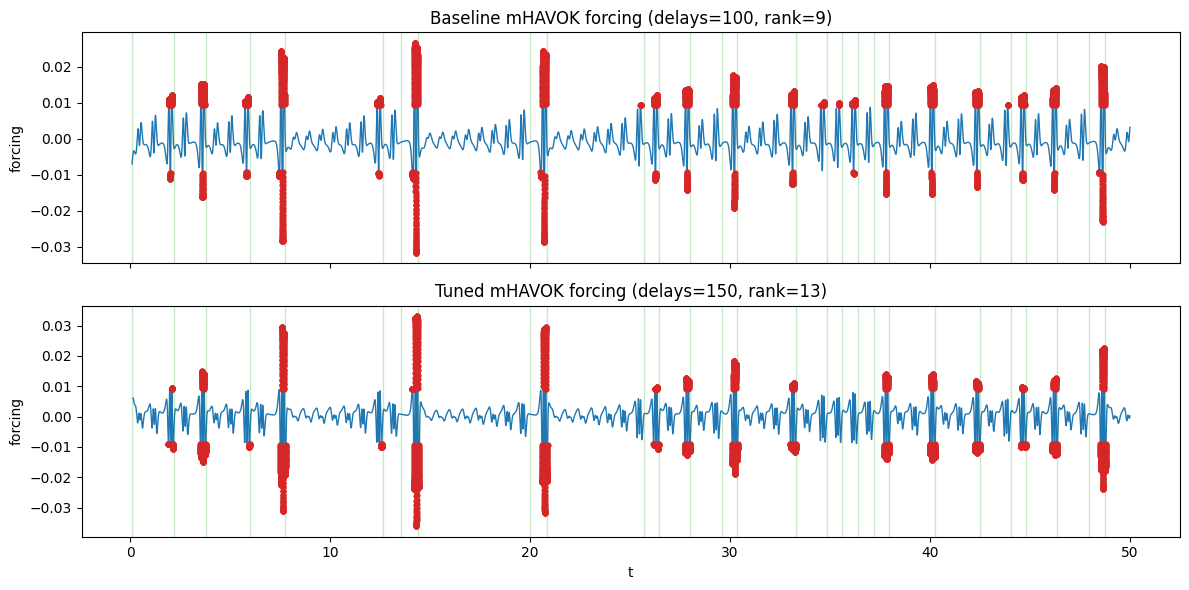

In [23]:
# Refit the best mHAVOK setting from the sweep and compare to the baseline
best_setting = sorted_results[0]
best_result = evaluate_mhavok_configuration(
    Y,
    t,
    dt,
    switch_times,
    best_setting["delays"],
    best_setting["rank"],
    return_series=True,
)

baseline_summary = {
    "delays": delays,
    "rank": r,
    "median_abs_gap": float(np.median(np.abs(nearest_signed_gaps))),
    "median_signed_gap": float(np.median(nearest_signed_gaps)),
    "fraction_within_0p10": float(np.mean(np.abs(nearest_signed_gaps) <= 0.10)),
}

print("Baseline configuration:")
print(
    f"delays={baseline_summary['delays']}, rank={baseline_summary['rank']}, "
    f"median |gap|={baseline_summary['median_abs_gap']:.4f} s, "
    f"median signed gap={baseline_summary['median_signed_gap']:.4f} s, "
    f"fraction within 0.10 s={baseline_summary['fraction_within_0p10']:.3f}"
)
print()
print("Best configuration from sweep:")
print(
    f"delays={best_result['delays']}, rank={best_result['rank']}, "
    f"median |gap|={best_result['median_abs_gap']:.4f} s, "
    f"median signed gap={best_result['median_signed_gap']:.4f} s, "
    f"fraction within 0.10 s={best_result['fraction_within_0p10']:.3f}"
)
print()
print(
    "Improvement in median absolute switch gap: "
    f"{baseline_summary['median_abs_gap'] - best_result['median_abs_gap']:.4f} s"
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(time_havok, forcing, lw=1.0, color="tab:blue")
axes[0].scatter(
    time_havok[active_forcing],
    forcing[active_forcing],
    color="tab:red",
    s=12,
    zorder=3,
)
for switch_time in switch_times:
    axes[0].axvline(switch_time, color="tab:green", alpha=0.25, linewidth=1.0)
axes[0].set_title(f"Baseline mHAVOK forcing (delays={delays}, rank={r})")
axes[0].set_ylabel("forcing")

axes[1].plot(best_result["time_havok"], best_result["forcing"], lw=1.0, color="tab:blue")
axes[1].scatter(
    best_result["time_havok"][best_result["active_forcing"]],
    best_result["forcing"][best_result["active_forcing"]],
    color="tab:red",
    s=12,
    zorder=3,
)
for switch_time in switch_times:
    axes[1].axvline(switch_time, color="tab:green", alpha=0.25, linewidth=1.0)
axes[1].set_title(
    f"Tuned mHAVOK forcing (delays={best_result['delays']}, rank={best_result['rank']})"
)
axes[1].set_xlabel("t")
axes[1].set_ylabel("forcing")

plt.tight_layout()
plt.show()

Tuned-model component R² scores:
component     R²
       v1 1.0000
       v2 1.0000
       v3 1.0000
       v4 1.0000
       v5 1.0000
       v6 1.0000
       v7 1.0000
       v8 0.9991
       v9 0.9989
      v10 0.9992
      v11 0.9986
      v12 0.3957


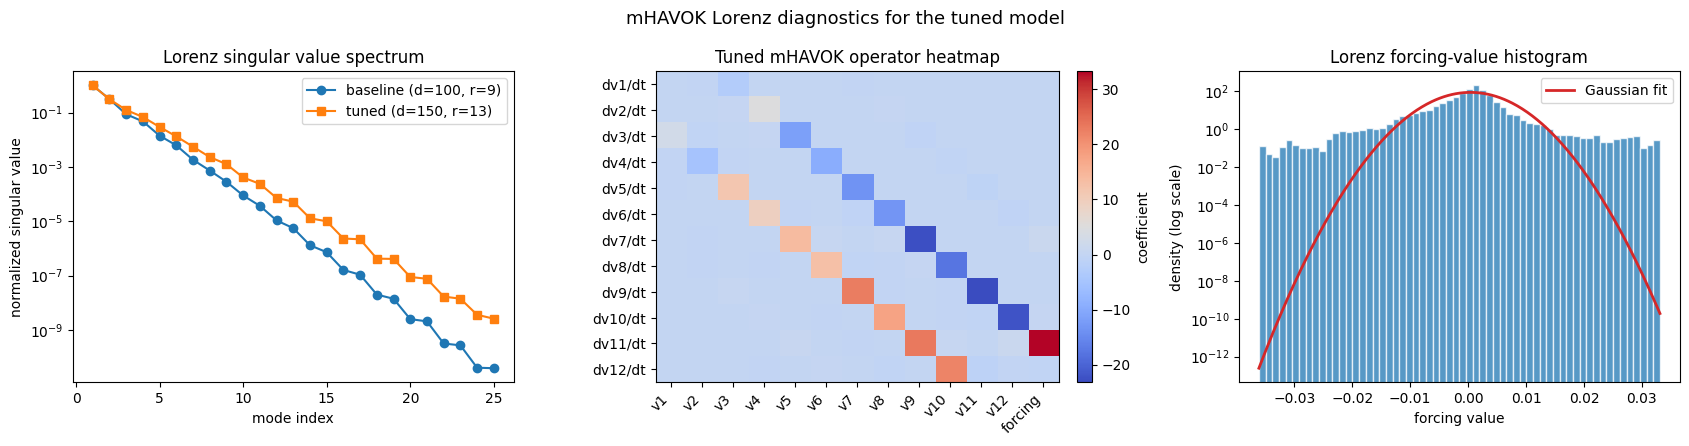

In [24]:
from scipy.stats import norm

# Plot the Lorenz singular spectrum, augmented operator, and forcing distribution
baseline_singular_values = S / S[0]
tuned_singular_values = best_result["singular_values"] / best_result["singular_values"][0]
max_modes = min(25, len(baseline_singular_values), len(tuned_singular_values))
modes = np.arange(1, max_modes + 1)

component_r2_df = pd.DataFrame(
    {
        "component": [f"v{i + 1}" for i in range(len(best_result["component_r2"]))],
        "R²": best_result["component_r2"],
    }
)
print("Tuned-model component R² scores:")
print(component_r2_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].semilogy(
    modes,
    baseline_singular_values[:max_modes],
    marker="o",
    linewidth=1.5,
    label=f"baseline (d={delays}, r={r})",
)
axes[0].semilogy(
    modes,
    tuned_singular_values[:max_modes],
    marker="s",
    linewidth=1.5,
    label=f"tuned (d={best_result['delays']}, r={best_result['rank']})",
)
axes[0].set_xlabel("mode index")
axes[0].set_ylabel("normalized singular value")
axes[0].set_title("Lorenz singular value spectrum")
axes[0].legend()

operator_matrix = best_result["augmented_operator"]
operator_image = axes[1].imshow(operator_matrix, cmap="coolwarm", aspect="auto")
input_labels = [f"v{i + 1}" for i in range(operator_matrix.shape[1] - 1)] + ["forcing"]
output_labels = [f"dv{i + 1}/dt" for i in range(operator_matrix.shape[0])]
axes[1].set_xticks(range(len(input_labels)))
axes[1].set_xticklabels(input_labels, rotation=45, ha="right")
axes[1].set_yticks(range(len(output_labels)))
axes[1].set_yticklabels(output_labels)
axes[1].set_title("Tuned mHAVOK operator heatmap")
fig.colorbar(operator_image, ax=axes[1], fraction=0.046, pad=0.04, label="coefficient")

forcing_values = best_result["forcing"]
forcing_grid = np.linspace(forcing_values.min(), forcing_values.max(), 400)
forcing_mean = forcing_values.mean()
forcing_std = forcing_values.std(ddof=1)
axes[2].hist(
    forcing_values,
    bins=60,
    density=True,
    alpha=0.75,
    color="tab:blue",
    edgecolor="white",
)
axes[2].plot(
    forcing_grid,
    norm.pdf(forcing_grid, loc=forcing_mean, scale=forcing_std),
    color="tab:red",
    linewidth=2,
    label="Gaussian fit",
)
axes[2].set_yscale("log")
axes[2].set_xlabel("forcing value")
axes[2].set_ylabel("density (log scale)")
axes[2].set_title("Lorenz forcing-value histogram")
axes[2].legend()

plt.suptitle("mHAVOK Lorenz diagnostics for the tuned model", fontsize=13)
plt.tight_layout()
plt.show()

Best x only: delays=150, rank=5, median |gap|=0.0625 s, median signed gap=-0.0180 s, fraction within 0.10 s=0.679, fraction preceding=0.679
Best z only: delays=150, rank=9, median |gap|=0.0070 s, median signed gap=0.0000 s, fraction within 0.10 s=0.607, fraction preceding=0.607
Best x and z: delays=150, rank=13, median |gap|=0.0275 s, median signed gap=0.0000 s, fraction within 0.10 s=0.607, fraction preceding=0.643


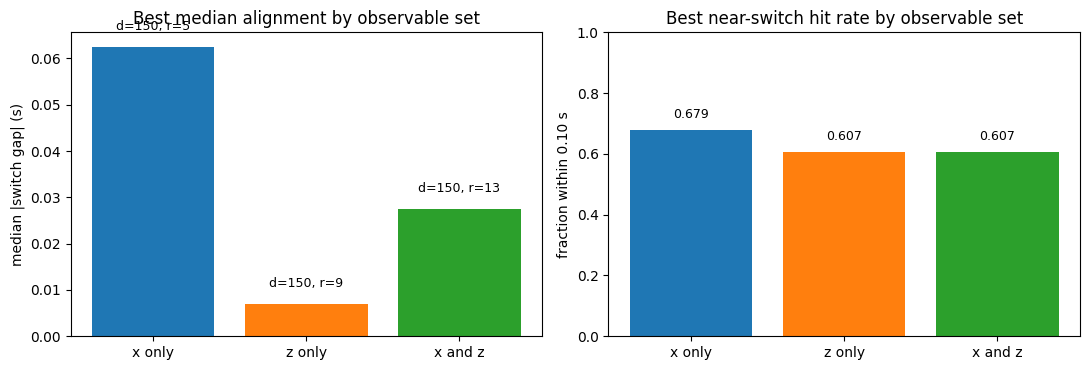

In [16]:
# Compare observable sets: single-channel HAVOK vs multichannel mHAVOK
channel_sets = {
    "x only": X[[0], :],
    "z only": X[[2], :],
    "x and z": X[[0, 2], :],
}

channel_results = []
for channel_name, channel_data in channel_sets.items():
    best_channel_result = None
    for trial_delays in delay_grid:
        for trial_rank in rank_grid:
            result = evaluate_mhavok_configuration(
                channel_data,
                t,
                dt,
                switch_times,
                trial_delays,
                trial_rank,
            )
            result["channel_name"] = channel_name
            channel_results.append(result)
            if best_channel_result is None or (
                result["median_abs_gap"],
                -result["fraction_within_0p10"],
            ) < (
                best_channel_result["median_abs_gap"],
                -best_channel_result["fraction_within_0p10"],
            ):
                best_channel_result = result
    print(
        f"Best {channel_name}: delays={best_channel_result['delays']}, "
        f"rank={best_channel_result['rank']}, "
        f"median |gap|={best_channel_result['median_abs_gap']:.4f} s, "
        f"median signed gap={best_channel_result['median_signed_gap']:.4f} s, "
        f"fraction within 0.10 s={best_channel_result['fraction_within_0p10']:.3f}, "
        f"fraction preceding={best_channel_result['fraction_preceding']:.3f}"
    )

best_by_channel = []
for channel_name in channel_sets:
    best_by_channel.append(
        min(
            [row for row in channel_results if row["channel_name"] == channel_name],
            key=lambda row: (row["median_abs_gap"], -row["fraction_within_0p10"]),
        )
    )

bar_positions = np.arange(len(best_by_channel))
bar_colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

median_gaps = [row["median_abs_gap"] for row in best_by_channel]
axes[0].bar(bar_positions, median_gaps, color=bar_colors)
axes[0].set_xticks(bar_positions)
axes[0].set_xticklabels([row["channel_name"] for row in best_by_channel])
axes[0].set_ylabel("median |switch gap| (s)")
axes[0].set_title("Best median alignment by observable set")
for idx, row in enumerate(best_by_channel):
    axes[0].text(
        idx,
        row["median_abs_gap"] + 0.003,
        f"d={row['delays']}, r={row['rank']}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fraction_within = [row["fraction_within_0p10"] for row in best_by_channel]
axes[1].bar(bar_positions, fraction_within, color=bar_colors)
axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels([row["channel_name"] for row in best_by_channel])
axes[1].set_ylabel("fraction within 0.10 s")
axes[1].set_ylim(0, 1)
axes[1].set_title("Best near-switch hit rate by observable set")
for idx, row in enumerate(best_by_channel):
    axes[1].text(
        idx,
        row["fraction_within_0p10"] + 0.03,
        f"{row['fraction_within_0p10']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Best model from each observable set:
observable set  delays  rank  median |gap| (s)  median signed gap (s)  fraction within 0.10 s  fraction preceding
        z only     150     9            0.0070                  0.000                  0.6071              0.6071
       x and z     150    13            0.0275                  0.000                  0.6071              0.6429
        x only     150     5            0.0625                 -0.018                  0.6786              0.6786


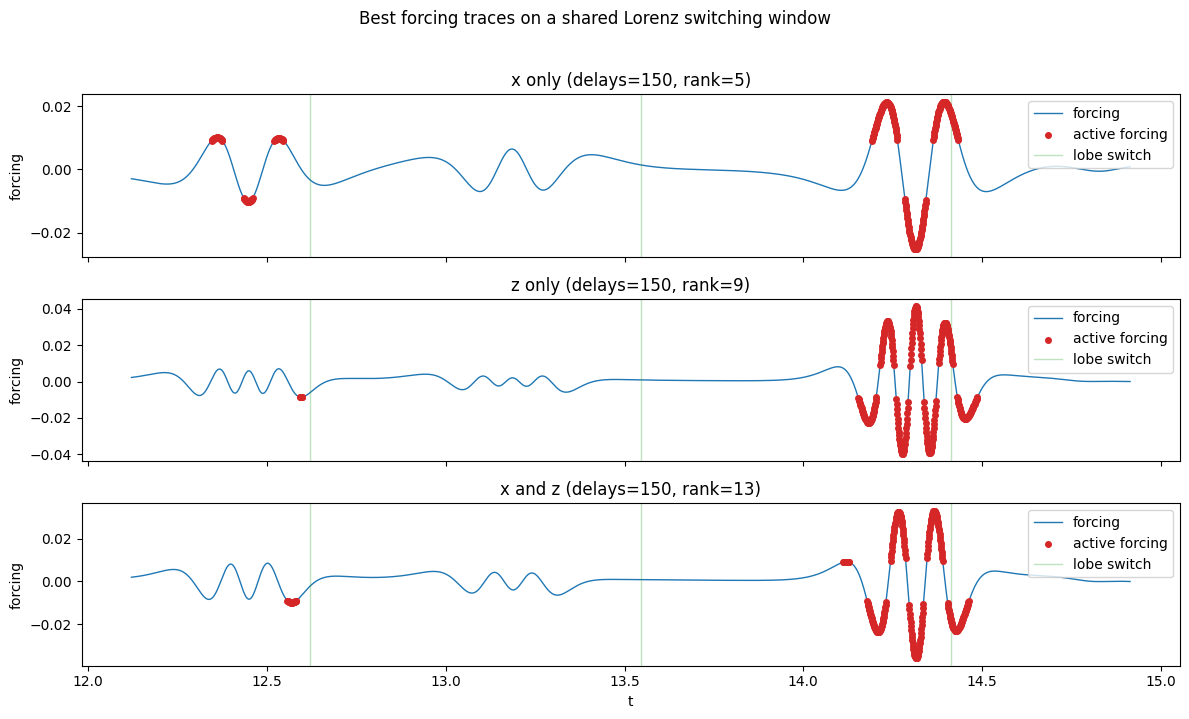

In [17]:
# Summarize the best observable-set models and compare them on one switch-rich window
import pandas as pd

best_channel_detailed = {}
for row in best_by_channel:
    detailed_result = evaluate_mhavok_configuration(
        channel_sets[row["channel_name"]],
        t,
        dt,
        switch_times,
        row["delays"],
        row["rank"],
        return_series=True,
    )
    detailed_result["channel_name"] = row["channel_name"]
    best_channel_detailed[row["channel_name"]] = detailed_result

summary_df = pd.DataFrame(
    [
        {
            "observable set": result["channel_name"],
            "delays": result["delays"],
            "rank": result["rank"],
            "median |gap| (s)": result["median_abs_gap"],
            "median signed gap (s)": result["median_signed_gap"],
            "fraction within 0.10 s": result["fraction_within_0p10"],
            "fraction preceding": result["fraction_preceding"],
        }
        for result in best_channel_detailed.values()
    ]
).sort_values("median |gap| (s)")

print("Best model from each observable set:")
print(summary_df.round(4).to_string(index=False))

window_start = switch_times[5] - 0.5
window_end = switch_times[7] + 0.5
window_switches = switch_times[(switch_times >= window_start) & (switch_times <= window_end)]
plot_order = ["x only", "z only", "x and z"]

fig, axes = plt.subplots(len(plot_order), 1, figsize=(12, 7), sharex=True)
for ax, channel_name in zip(axes, plot_order):
    result = best_channel_detailed[channel_name]
    time_mask = (result["time_havok"] >= window_start) & (result["time_havok"] <= window_end)
    active_mask = result["active_forcing"] & time_mask
    ax.plot(
        result["time_havok"][time_mask],
        result["forcing"][time_mask],
        color="tab:blue",
        lw=1.0,
        label="forcing",
    )
    ax.scatter(
        result["time_havok"][active_mask],
        result["forcing"][active_mask],
        color="tab:red",
        s=16,
        zorder=3,
        label="active forcing",
    )
    for idx, switch_time in enumerate(window_switches):
        label = "lobe switch" if idx == 0 else None
        ax.axvline(switch_time, color="tab:green", alpha=0.3, linewidth=1.0, label=label)
    ax.set_title(
        f"{channel_name} (delays={result['delays']}, rank={result['rank']})"
    )
    ax.set_ylabel("forcing")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("t")
fig.suptitle("Best forcing traces on a shared Lorenz switching window", y=1.02)
plt.tight_layout()
plt.show()

Signed-gap distribution summary for the best model in each observable set:
observable set  median signed gap (s)  25th percentile (s)  75th percentile (s)  min gap (s)  max gap (s)  fraction preceding
        x only                 -0.018              -0.0505               0.4935       -0.277        0.645              0.6786
        z only                  0.000              -0.0005               0.5420       -1.519        2.095              0.6071
       x and z                  0.000              -0.0107               0.5078       -1.541        2.087              0.6429


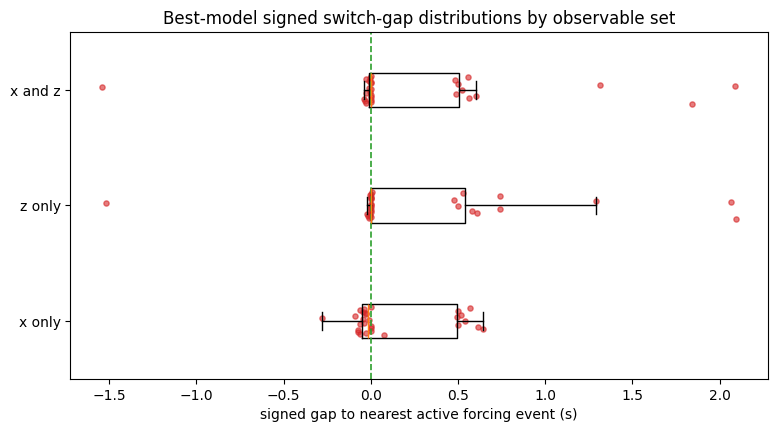

In [18]:
# Compare signed switch-gap distributions for the best model from each observable set
gap_summary_df = pd.DataFrame(
    [
        {
            "observable set": channel_name,
            "median signed gap (s)": np.median(result["nearest_signed_gaps"]),
            "25th percentile (s)": np.quantile(result["nearest_signed_gaps"], 0.25),
            "75th percentile (s)": np.quantile(result["nearest_signed_gaps"], 0.75),
            "min gap (s)": np.min(result["nearest_signed_gaps"]),
            "max gap (s)": np.max(result["nearest_signed_gaps"]),
            "fraction preceding": np.mean(result["nearest_signed_gaps"] <= 0),
        }
        for channel_name, result in best_channel_detailed.items()
    ]
).sort_values("median signed gap (s)")

print("Signed-gap distribution summary for the best model in each observable set:")
print(gap_summary_df.round(4).to_string(index=False))

plot_order = ["x only", "z only", "x and z"]
plot_data = [best_channel_detailed[name]["nearest_signed_gaps"] for name in plot_order]

plt.figure(figsize=(9, 4.5))
plt.boxplot(plot_data, tick_labels=plot_order, vert=False, showfliers=False)
for row_index, channel_name in enumerate(plot_order, start=1):
    y_values = np.full_like(best_channel_detailed[channel_name]["nearest_signed_gaps"], row_index, dtype=float)
    jitter = np.linspace(-0.12, 0.12, len(y_values))
    plt.scatter(
        best_channel_detailed[channel_name]["nearest_signed_gaps"],
        y_values + jitter,
        s=14,
        alpha=0.6,
        color="tab:red",
    )
plt.axvline(0, color="tab:green", linestyle="--", linewidth=1.2)
plt.xlabel("signed gap to nearest active forcing event (s)")
plt.title("Best-model signed switch-gap distributions by observable set")
plt.show()

Objective-based winners across the best model from each observable set:
tight alignment: z only (score=0.600)
balanced: x only (score=0.600)
early warning: x only (score=0.800)


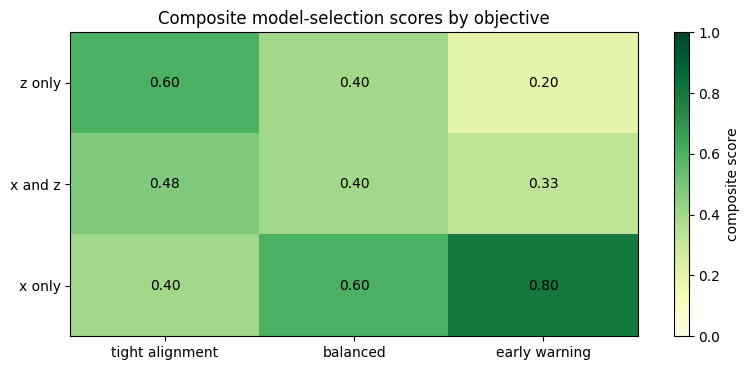

In [20]:
# Objective-based model selection for the best model in each observable set
selection_df = summary_df.copy().reset_index(drop=True)

median_gap_values = selection_df["median |gap| (s)"].to_numpy()
fraction_within_values = selection_df["fraction within 0.10 s"].to_numpy()
fraction_preceding_values = selection_df["fraction preceding"].to_numpy()

selection_df["gap score"] = 1 - (
    (median_gap_values - median_gap_values.min())
    / (median_gap_values.max() - median_gap_values.min())
)
selection_df["within-0.10 score"] = (
    (fraction_within_values - fraction_within_values.min())
    / (fraction_within_values.max() - fraction_within_values.min())
)
selection_df["preceding score"] = (
    (fraction_preceding_values - fraction_preceding_values.min())
    / (fraction_preceding_values.max() - fraction_preceding_values.min())
)

selection_profiles = {
    "tight alignment": {
        "gap score": 0.60,
        "within-0.10 score": 0.20,
        "preceding score": 0.20,
    },
    "balanced": {
        "gap score": 0.40,
        "within-0.10 score": 0.30,
        "preceding score": 0.30,
    },
    "early warning": {
        "gap score": 0.20,
        "within-0.10 score": 0.40,
        "preceding score": 0.40,
    },
}

profile_winners = []
for profile_name, weights in selection_profiles.items():
    composite_score = (
        weights["gap score"] * selection_df["gap score"]
        + weights["within-0.10 score"] * selection_df["within-0.10 score"]
        + weights["preceding score"] * selection_df["preceding score"]
    )
    selection_df[f"score: {profile_name}"] = composite_score
    winner_index = composite_score.idxmax()
    winner = selection_df.loc[winner_index]
    profile_winners.append(
        {
            "objective": profile_name,
            "winner": winner["observable set"],
            "score": winner[f"score: {profile_name}"],
        }
    )

print("Objective-based winners across the best model from each observable set:")
for row in profile_winners:
    print(f"{row['objective']}: {row['winner']} (score={row['score']:.3f})")

score_columns = [f"score: {name}" for name in selection_profiles]
score_matrix = selection_df[score_columns].to_numpy()

fig, ax = plt.subplots(figsize=(8, 3.8))
image = ax.imshow(score_matrix, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(score_columns)))
ax.set_xticklabels(list(selection_profiles.keys()))
ax.set_yticks(range(len(selection_df)))
ax.set_yticklabels(selection_df["observable set"])
ax.set_title("Composite model-selection scores by objective")
for row_index in range(score_matrix.shape[0]):
    for col_index in range(score_matrix.shape[1]):
        ax.text(
            col_index,
            row_index,
            f"{score_matrix[row_index, col_index]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
fig.colorbar(image, ax=ax, label="composite score")
plt.tight_layout()
plt.show()

Best model from each observable combination:
channel combo  delays  rank  event recall  event precision  event accuracy  event F1  mean linear R²  Chamfer distance (s)  median |gap| (s)
        x+y+z     150     5        0.7143           0.4878          0.8924    0.5797          0.7450                0.1488            0.0005
          x+y     150     5        0.6429           0.3273          0.8794    0.4337          0.9988                0.2095            0.0605
            x     150     5        0.6429           0.3214          0.8792    0.4286          0.9995                0.1937            0.0625
          y+z     150    11        0.6786           0.2754          0.8810    0.3918          0.9403                0.2083            0.0535
          x+z     150    11        0.6429           0.2535          0.8801    0.3636          0.9382                0.2352            0.0480
            z     150     7        0.6429           0.2278          0.8875    0.3364          0.9996         

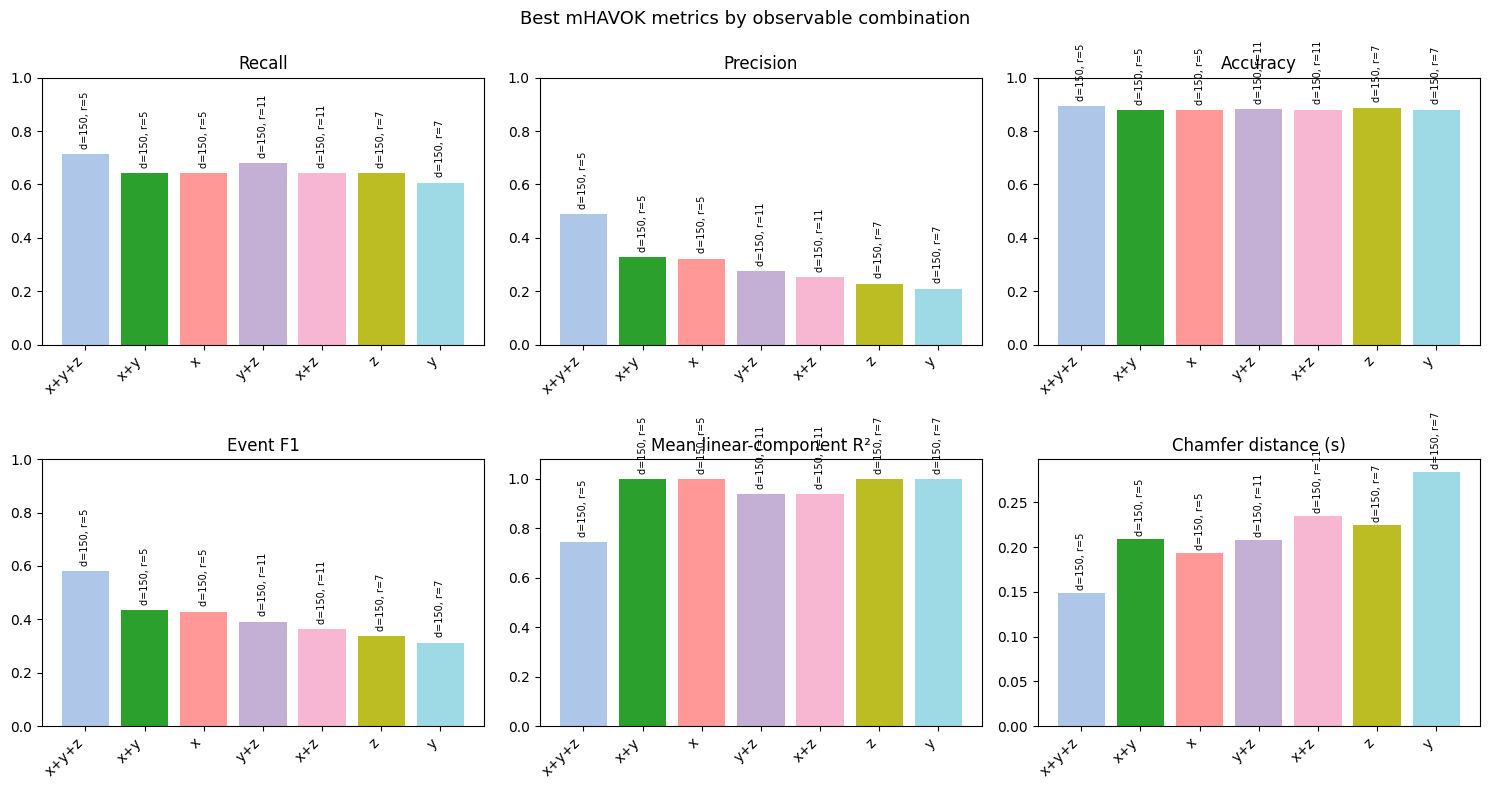

In [25]:
# Benchmark all single-, double-, and triple-channel observable combinations
all_channel_sets = {
    "x": X[[0], :],
    "y": X[[1], :],
    "z": X[[2], :],
    "x+y": X[[0, 1], :],
    "x+z": X[[0, 2], :],
    "y+z": X[[1, 2], :],
    "x+y+z": X[[0, 1, 2], :],
}

combo_best_rows = []
combo_best_detailed = {}
for combo_name, combo_data in all_channel_sets.items():
    combo_results = []
    for trial_delays in delay_grid:
        for trial_rank in rank_grid:
            result = evaluate_mhavok_configuration(
                combo_data,
                t,
                dt,
                switch_times,
                trial_delays,
                trial_rank,
                event_tolerance=event_tolerance,
            )
            result["channel combo"] = combo_name
            combo_results.append(result)

    best_combo_result = max(
        combo_results,
        key=lambda row: (
            row["event_f1"],
            row["event_recall"],
            row["event_precision"],
            row["mean_linear_r2"],
            -row["chamfer_distance"],
        ),
    )
    best_combo_detailed = evaluate_mhavok_configuration(
        combo_data,
        t,
        dt,
        switch_times,
        best_combo_result["delays"],
        best_combo_result["rank"],
        event_tolerance=event_tolerance,
        return_series=True,
    )
    best_combo_detailed["channel combo"] = combo_name
    combo_best_detailed[combo_name] = best_combo_detailed

    combo_best_rows.append(
        {
            "channel combo": combo_name,
            "delays": best_combo_result["delays"],
            "rank": best_combo_result["rank"],
            "event recall": best_combo_result["event_recall"],
            "event precision": best_combo_result["event_precision"],
            "event accuracy": best_combo_result["event_accuracy"],
            "event F1": best_combo_result["event_f1"],
            "mean linear R²": best_combo_result["mean_linear_r2"],
            "Chamfer distance (s)": best_combo_result["chamfer_distance"],
            "median |gap| (s)": best_combo_result["median_abs_gap"],
        }
    )

combo_best_df = pd.DataFrame(combo_best_rows).sort_values(
    ["event F1", "event recall", "event precision", "mean linear R²", "Chamfer distance (s)"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

print("Best model from each observable combination:")
print(combo_best_df.round(4).to_string(index=False))

combo_positions = np.arange(len(combo_best_df))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
combo_metric_specs = [
    ("event recall", "Recall"),
    ("event precision", "Precision"),
    ("event accuracy", "Accuracy"),
    ("event F1", "Event F1"),
    ("mean linear R²", "Mean linear-component R²"),
    ("Chamfer distance (s)", "Chamfer distance (s)"),
]

for ax, (metric_key, title) in zip(axes.flat, combo_metric_specs):
    values = combo_best_df[metric_key].to_numpy()
    ax.bar(combo_positions, values, color=plt.cm.tab20(np.linspace(0.05, 0.95, len(combo_positions))))
    ax.set_xticks(combo_positions)
    ax.set_xticklabels(combo_best_df["channel combo"], rotation=45, ha="right")
    if metric_key != "Chamfer distance (s)":
        ax.set_ylim(0, max(1.0, 1.08 * values.max()))
    ax.set_title(title)
    for idx, row in combo_best_df.iterrows():
        offset = 0.02 if metric_key != "Chamfer distance (s)" else 0.01 * max(values.max(), 1e-6)
        ax.text(
            idx,
            values[idx] + offset,
            f"d={row['delays']}, r={row['rank']}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

plt.suptitle("Best mHAVOK metrics by observable combination", fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Export slide-ready summary tables
from pathlib import Path

output_dir = Path("plots") / "mhavok_lorenz"
output_dir.mkdir(parents=True, exist_ok=True)

summary_export_path = output_dir / "best_observable_models.csv"
gap_export_path = output_dir / "signed_gap_summary.csv"
selection_export_path = output_dir / "objective_model_selection.csv"
sweep_export_path = output_dir / "rank_delay_event_metrics.csv"
combo_export_path = output_dir / "all_channel_combo_metrics.csv"
component_r2_export_path = output_dir / "tuned_component_r2.csv"

summary_df.round(4).to_csv(summary_export_path, index=False)
gap_summary_df.round(4).to_csv(gap_export_path, index=False)
selection_df.round(4).to_csv(selection_export_path, index=False)
sweep_metrics_df.round(4).to_csv(sweep_export_path, index=False)
combo_best_df.round(4).to_csv(combo_export_path, index=False)
component_r2_df.round(4).to_csv(component_r2_export_path, index=False)

print("Exported summary tables:")
print(summary_export_path)
print(gap_export_path)
print(selection_export_path)
print(sweep_export_path)
print(combo_export_path)
print(component_r2_export_path)

Exported summary tables:
plots/mhavok_lorenz/best_observable_models.csv
plots/mhavok_lorenz/signed_gap_summary.csv
plots/mhavok_lorenz/objective_model_selection.csv
plots/mhavok_lorenz/rank_delay_event_metrics.csv
plots/mhavok_lorenz/all_channel_combo_metrics.csv
plots/mhavok_lorenz/tuned_component_r2.csv


## Implemented Tasks

- Rank and delay sweep now reports **recall, precision, accuracy, event F1, mean linear-component R²**, and the original switch-gap metrics.
- Lorenz diagnostics now include a **singular value spectrum**, **tuned operator heatmap**, and **forcing-value histogram**.
- Full observable benchmarking now compares **all single-, double-, and triple-channel combinations** of `x`, `y`, and `z`.
- The multichannel comparison now reports **Chamfer distance** in addition to recall, precision, accuracy, and R²-style regression quality.
- Updated notebook exports now include slide-ready CSVs for the **rank-delay sweep**, **all channel combinations**, and **tuned component R² scores**.

## Current Takeaways

- On the tested rank-delay grid, the best **event-F1** model for the default `x and z` setup is `delays = 150`, `rank = 11`, while the best **median gap** model remains `delays = 150`, `rank = 13`.
- Across all observable combinations, the best event-detection model is **`x+y+z` with `delays = 150` and `rank = 5`**, with recall `0.714`, precision `0.488`, accuracy `0.892`, event F1 `0.580`, and Chamfer distance `0.149 s`.
- The previous `x only`, `z only`, and `x and z` comparison is still useful for narrow tradeoff studies, but the full combo benchmark shows that **adding `y` changes the ranking materially**.
- The tuned model’s regression fit is strong for most linear components, but the last linear component remains the weakest one, so **mode quality is not uniform across the embedding**.
- The main scientific conclusion so far is that **observable choice, objective choice, and metric choice all materially change what counts as the “best” mHAVOK model** for Lorenz switching.